# 02 Risk Analytics and Stress Testing

## Project context

This notebook builds Phase 1 of the Fixed Income and Balance Sheet Analytics Platform. Phase 0 created a synthetic bond book, cash flow schedule, pricing outputs, and portfolio market value summary. Phase 1 adds duration, convexity, DV01, parallel rate shocks, and a simple balance sheet interpretation.

The bond book is synthetic and for portfolio learning only.

## Risk analytics objective

- Calculate bond-level Macaulay duration, modified duration, convexity, and DV01.
- Summarize portfolio-level interest-rate sensitivity.
- Reprice the synthetic bond book under parallel rate shocks.
- Interpret stress losses by sector and rating.
- Create simple ALM-style notes for balance sheet sensitivity.

In [1]:
from pathlib import Path
import sys

import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

from src.config import PROCESSED_DATA_DIR, OUTPUTS_DIR, FIGURES_DIR
from src.risk import calculate_bond_risk_metrics, summarize_portfolio_risk
from src.scenarios import (
    create_rate_scenarios,
    run_stress_test,
    summarize_stress_results,
    create_simple_alm_summary,
)
from src.visualization import (
    plot_duration_by_bond,
    plot_convexity_by_bond,
    plot_dv01_by_bond,
    plot_portfolio_value_under_shocks,
    plot_stress_loss_by_group,
)

scenario_dir = OUTPUTS_DIR / "scenarios"
scenario_dir.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

settlement_date = pd.Timestamp("2026-04-30")

## Load bond book and pricing results

In [2]:
bond_book = pd.read_csv(PROCESSED_DATA_DIR / "synthetic_bond_book.csv", parse_dates=["issue_date", "maturity_date"])
cashflows = pd.read_csv(OUTPUTS_DIR / "bond_book" / "bond_cashflows.csv", parse_dates=["settlement_date", "cashflow_date"])
pricing_results = pd.read_csv(OUTPUTS_DIR / "pricing" / "bond_pricing_results.csv", parse_dates=["issue_date", "maturity_date", "settlement_date"])
portfolio_pricing_summary = pd.read_csv(OUTPUTS_DIR / "pricing" / "portfolio_pricing_summary.csv")

bond_book.shape, cashflows.shape, pricing_results.shape, portfolio_pricing_summary

((10, 11),
 (125, 13),
 (10, 17),
   settlement_date  bond_count  total_face_value  total_book_value  \
 0      2026-04-30          10           7500000           7295000   
 
    total_market_value  market_to_book_ratio  weighted_average_coupon  \
 0        7.226569e+06              0.990619                 0.053713   
 
    weighted_average_yield  
 0                0.059594  )

## Duration and convexity calculation

In [3]:
risk_results = calculate_bond_risk_metrics(pricing_results, cashflows)
risk_results.to_csv(scenario_dir / "bond_risk_metrics.csv", index=False)
risk_results

,bond_id,issuer_type,sector,credit_rating,market_value,market_yield,macaulay_duration,modified_duration,convexity,dv01
0,BOND001,Sovereign,Government,AA,9.846819e+05,0.050,1.646738,1.606574,3.434085,158.196411
1,BOND002,Bank,Financials,A,7.301279e+05,0.061,2.642863,2.564641,8.127601,187.251623
2,BOND003,Corporate,Utilities,A,5.935344e+05,0.066,3.660045,3.543122,15.409318,210.296480
3,BOND004,Corporate,Property,BBB,4.672716e+05,0.078,4.471945,4.386410,22.762389,204.964512
4,BOND005,Sovereign,Government,AA,1.229518e+06,0.044,1.503137,1.470780,2.942512,180.835077
5,BOND006,Corporate,Consumer,BBB,4.238732e+05,0.071,4.831512,4.665873,26.699006,197.773860
6,BOND007,Bank,Financials,A,8.715913e+05,0.058,4.515148,4.387899,23.203544,382.445468
7,BOND008,Corporate,Telecom,BBB,6.472221e+05,0.069,6.616222,6.395575,51.659128,413.935725
8,BOND009,Agency,Government-Linked,AA,7.830333e+05,0.052,1.920712,1.872039,4.488680,146.586876
9,BOND010,Corporate,Infrastructure,BBB,4.957151e+05,0.083,6.390377,6.260473,49.104852,310.341098


## DV01 calculation

DV01 estimates the market value change for a one basis point rate move. The sign convention here reports positive exposure amount; a rate increase would reduce bond value approximately by DV01 per basis point before convexity adjustment.

In [4]:
risk_results[["bond_id", "market_value", "modified_duration", "convexity", "dv01"]].sort_values("dv01", ascending=False)

,bond_id,market_value,modified_duration,convexity,dv01
7,BOND008,6.472221e+05,6.395575,51.659128,413.935725
6,BOND007,8.715913e+05,4.387899,23.203544,382.445468
9,BOND010,4.957151e+05,6.260473,49.104852,310.341098
2,BOND003,5.935344e+05,3.543122,15.409318,210.296480
3,BOND004,4.672716e+05,4.386410,22.762389,204.964512
5,BOND006,4.238732e+05,4.665873,26.699006,197.773860
1,BOND002,7.301279e+05,2.564641,8.127601,187.251623
4,BOND005,1.229518e+06,1.470780,2.942512,180.835077
0,BOND001,9.846819e+05,1.606574,3.434085,158.196411
8,BOND009,7.830333e+05,1.872039,4.488680,146.586876


## Portfolio risk summary

In [5]:
portfolio_risk_summary = summarize_portfolio_risk(risk_results)
portfolio_risk_summary.to_csv(scenario_dir / "portfolio_risk_summary.csv", index=False)
portfolio_risk_summary.T

,0
bond_count,1.000000e+01
total_market_value,7.226569e+06
portfolio_macaulay_duration,3.403900e+00
portfolio_modified_duration,3.310876e+00
portfolio_convexity,1.737318e+01
portfolio_dv01,2.392627e+03
largest_single_bond_dv01,4.139357e+02


## Interest-rate stress scenarios

In [6]:
rate_scenarios = create_rate_scenarios()
rate_scenarios

,scenario,shock_bps,yield_change
0,-100 bps,-100,-0.010
1,-50 bps,-50,-0.005
2,base,0,0.000
3,+50 bps,50,0.005
4,+100 bps,100,0.010
5,+200 bps,200,0.020


In [7]:
stress_results = run_stress_test(
    bond_book=bond_book,
    shocks_bps=rate_scenarios["shock_bps"].tolist(),
    settlement_date=settlement_date,
)
stress_results.to_csv(scenario_dir / "rate_stress_results.csv", index=False)
stress_results.head()

,bond_id,issuer_type,sector,credit_rating,shock_bps,base_market_yield,shocked_market_yield,shocked_price,shocked_clean_price_per_100,shocked_market_value,base_price,base_market_value,base_clean_price_per_100,market_value_change,market_value_change_pct
0,BOND001,Sovereign,Government,AA,-100,0.050,0.040,1.021094e+06,102.109396,1.000672e+06,1.004777e+06,9.846819e+05,100.477742,15990.211216,0.016239
1,BOND002,Bank,Financials,A,-100,0.061,0.051,7.644423e+05,101.925639,7.491534e+05,7.450285e+05,7.301279e+05,99.337128,19025.554174,0.026058
2,BOND003,Corporate,Utilities,A,-100,0.066,0.056,6.254531e+05,104.242189,6.150289e+05,6.035943e+05,5.935344e+05,100.599048,21494.531459,0.036214
3,BOND004,Corporate,Property,BBB,-100,0.078,0.068,5.086562e+05,101.731241,4.883100e+05,4.867413e+05,4.672716e+05,97.348258,21038.319716,0.045024
4,BOND005,Sovereign,Government,AA,-100,0.044,0.034,1.278467e+06,102.277366,1.247784e+06,1.259752e+06,1.229518e+06,100.780160,18265.917243,0.014856


## Price impact by bond and portfolio

In [8]:
stress_summary = summarize_stress_results(stress_results)
stress_summary.to_csv(scenario_dir / "rate_stress_summary.csv", index=False)
stress_summary

,scenario,shock_bps,base_market_value,portfolio_market_value,market_value_change,market_value_change_pct
0,-100 bps,-100,7.226569e+06,7.472253e+06,245684.640739,0.033997
1,-50 bps,-50,7.226569e+06,7.347787e+06,121218.595487,0.016774
2,base,0,7.226569e+06,7.226569e+06,0.000000,0.000000
3,+50 bps,50,7.226569e+06,7.108489e+06,-118079.533963,-0.016340
4,+100 bps,100,7.226569e+06,6.993445e+06,-233124.191629,-0.032259
5,+200 bps,200,7.226569e+06,6.772063e+06,-454505.678786,-0.062894


## Sector and rating risk concentration

In [9]:
sector_stress = (
    stress_results[stress_results["shock_bps"] == 100]
    .groupby("sector", as_index=False)["market_value_change"]
    .sum()
    .assign(stress_loss=lambda df: -df["market_value_change"])
    .sort_values("stress_loss", ascending=False)
)
rating_stress = (
    stress_results[stress_results["shock_bps"] == 100]
    .groupby("credit_rating", as_index=False)["market_value_change"]
    .sum()
    .assign(stress_loss=lambda df: -df["market_value_change"])
    .sort_values("stress_loss", ascending=False)
)
sector_stress, rating_stress

(              sector  market_value_change   stress_loss
 1         Financials        -55684.895477  55684.895477
 6            Telecom        -39770.215061  39770.215061
 2         Government        -33556.147441  33556.147441
 4     Infrastructure        -29850.833887  29850.833887
 7          Utilities        -20579.732465  20579.732465
 5           Property        -19974.405401  19974.405401
 0           Consumer        -19223.331255  19223.331255
 3  Government-Linked        -14484.630641  14484.630641,
   credit_rating  market_value_change    stress_loss
 2           BBB       -108818.785605  108818.785605
 0             A        -76264.627942   76264.627942
 1            AA        -48040.778082   48040.778082)

## Simple ALM / balance sheet interpretation

In [10]:
alm_summary = create_simple_alm_summary(
    portfolio_market_value=float(portfolio_risk_summary["total_market_value"].iloc[0]),
    stress_summary=stress_summary,
)
alm_summary.to_csv(scenario_dir / "simple_alm_summary.csv", index=False)
alm_summary

,measure,value,interpretation
0,base_portfolio_market_value,7.226569e+06,Current modeled market value of the synthetic ...
1,plus_100_bps_market_value_change,-2.331242e+05,Estimated loss from a 100 bps parallel upward ...
2,plus_200_bps_market_value_change,-4.545057e+05,Larger rate shock loss proxy for balance sheet...
3,minus_100_bps_market_value_change,2.456846e+05,Estimated gain from a 100 bps downward rate sh...
4,market_value_to_input_check,7.226569e+06,Input portfolio market value used to anchor st...


## Figures

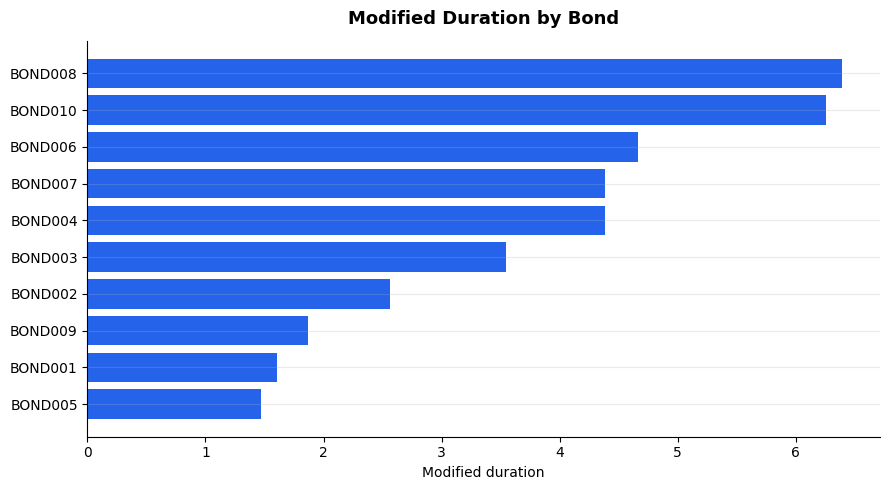

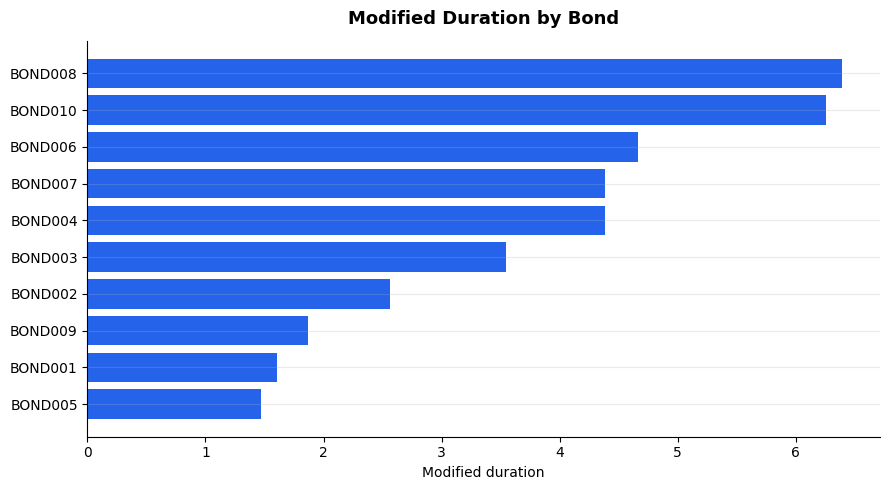

In [11]:
fig = plot_duration_by_bond(risk_results)
fig.savefig(FIGURES_DIR / "duration_by_bond.png", dpi=150, bbox_inches="tight")
fig

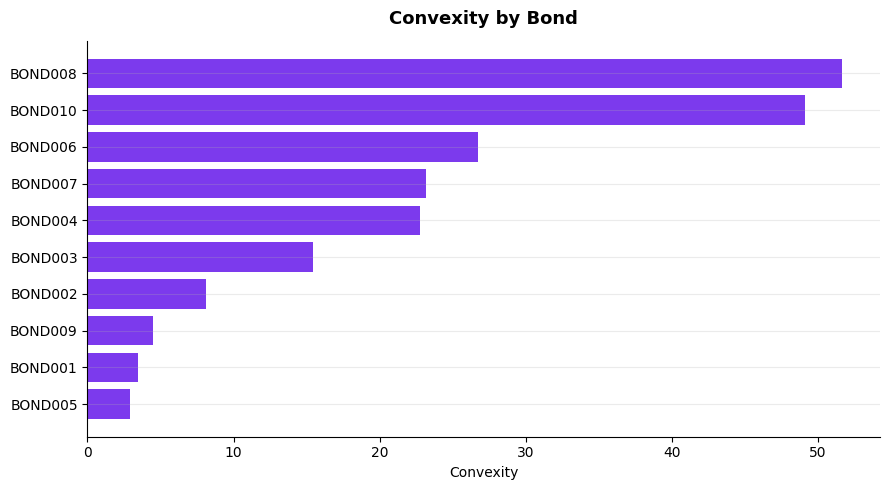

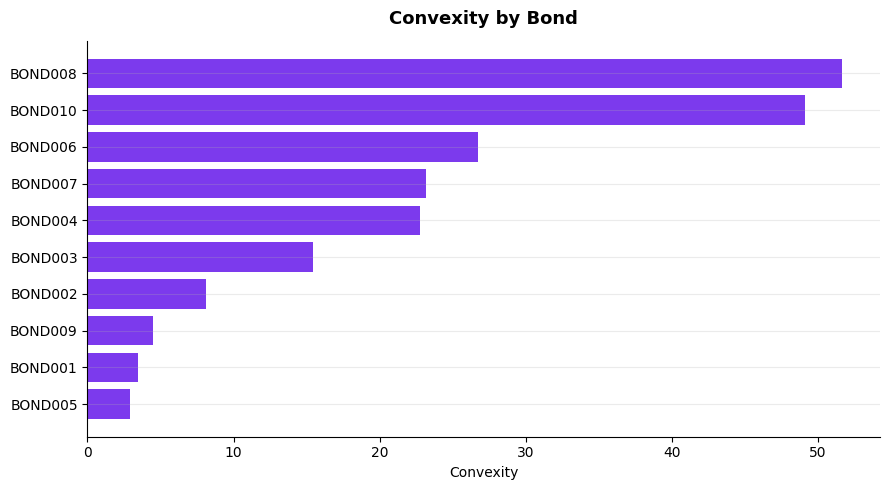

In [12]:
fig = plot_convexity_by_bond(risk_results)
fig.savefig(FIGURES_DIR / "convexity_by_bond.png", dpi=150, bbox_inches="tight")
fig

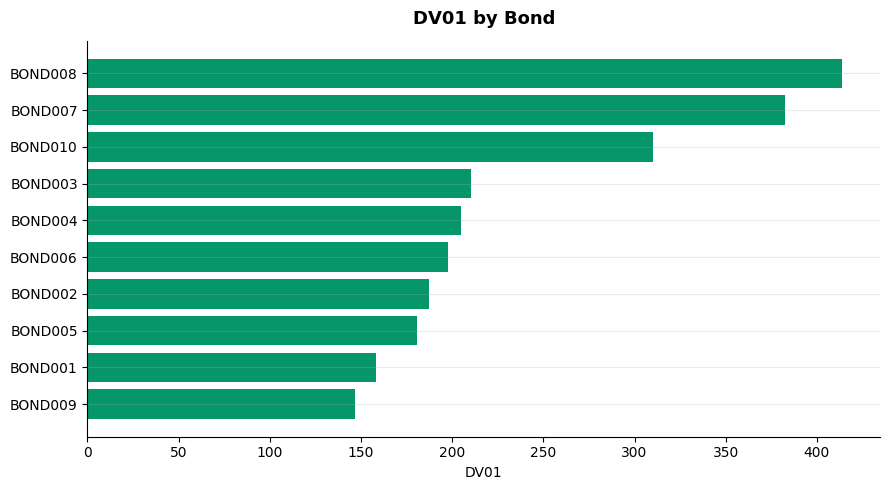

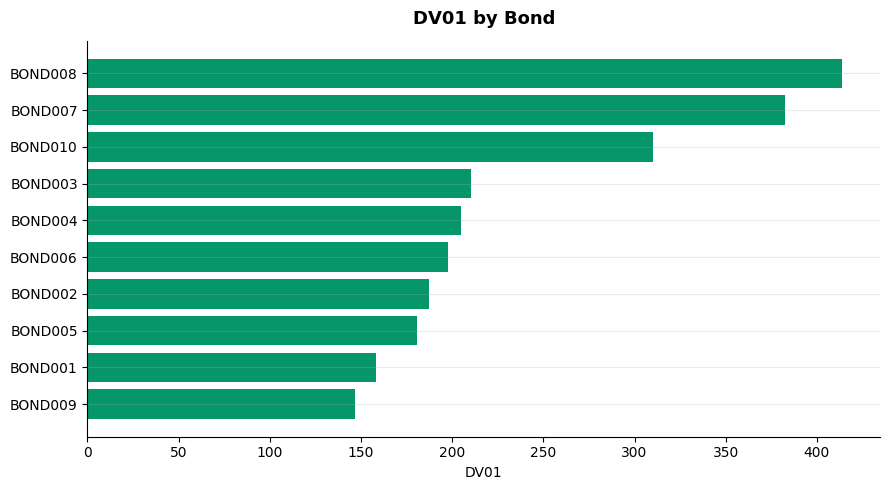

In [13]:
fig = plot_dv01_by_bond(risk_results)
fig.savefig(FIGURES_DIR / "dv01_by_bond.png", dpi=150, bbox_inches="tight")
fig

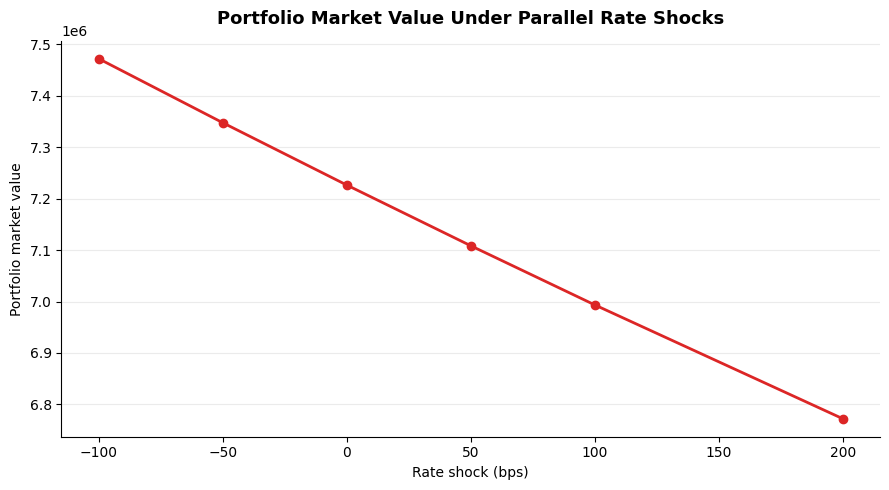

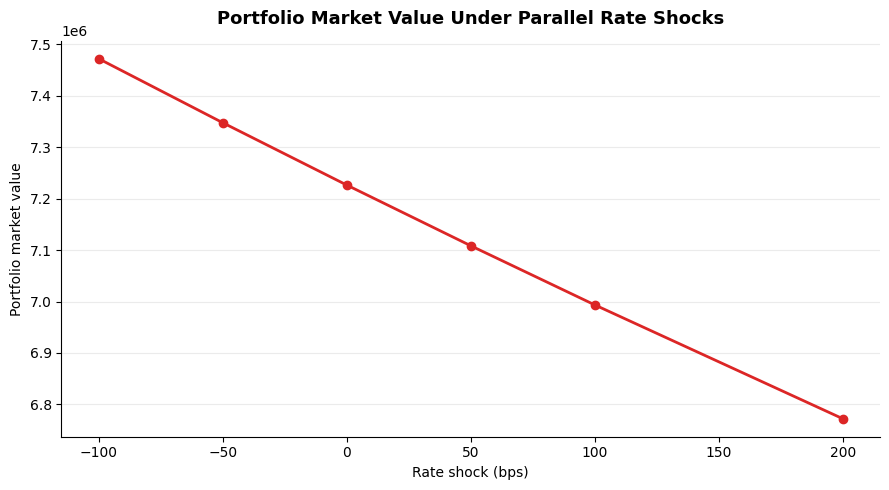

In [14]:
fig = plot_portfolio_value_under_shocks(stress_summary)
fig.savefig(FIGURES_DIR / "portfolio_value_under_rate_shocks.png", dpi=150, bbox_inches="tight")
fig

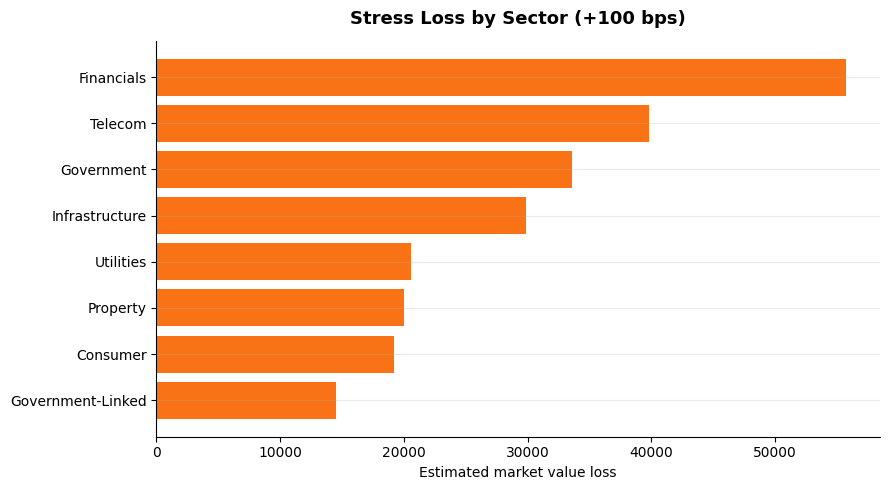

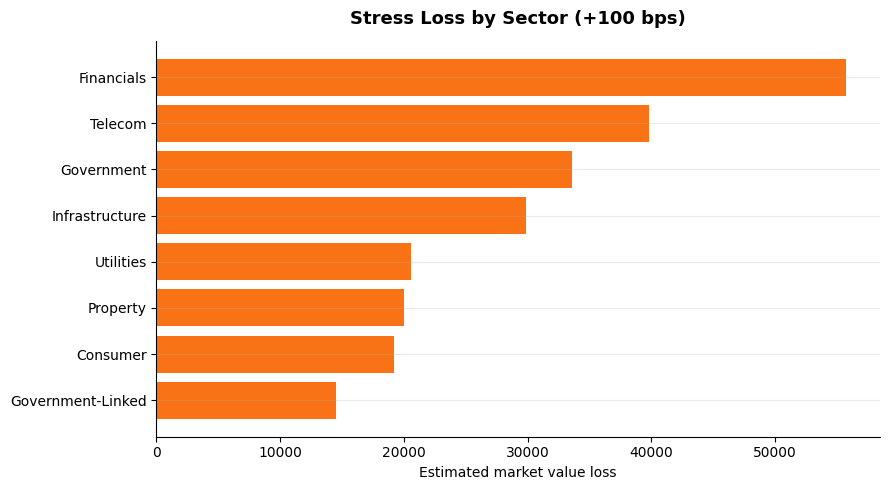

In [15]:
fig = plot_stress_loss_by_group(stress_results, group_col="sector", shock_bps=100)
fig.savefig(FIGURES_DIR / "stress_loss_by_sector.png", dpi=150, bbox_inches="tight")
fig

## Business interpretation

The synthetic portfolio has positive duration exposure, so parallel upward rate shocks reduce market value while downward shocks increase it. DV01 gives a compact balance sheet sensitivity measure: it estimates how much value changes for a one basis point move. Sector and rating cuts help identify where rate sensitivity is concentrated before adding real ALM assumptions.

## Limitations

- Synthetic bond book only.
- Parallel rate shocks only.
- No real yield curve calibration.
- No liquidity, credit spread, prepayment, or optionality modeling.
- ALM interpretation is simplified and does not include liabilities.

## Final project outputs

Phase 1 adds `bond_risk_metrics.csv`, `portfolio_risk_summary.csv`, `rate_stress_results.csv`, `rate_stress_summary.csv`, and `simple_alm_summary.csv` under `outputs/scenarios/`.

## Next steps for Phase 2 polish

- Polish the README and reports.
- Add resume bullets and interview talking points.
- Make limitations clear for recruiters and finance interviewers.